In [29]:
import numpy as np

def generate_supply_chain_data(W=8, C=30, seed=42):
    np.random.seed(seed)

    # Warehouse data
    opening_cost = np.random.uniform(100, 500, W)      # Cost to open
    holding_cost = np.random.uniform(1, 10, W)         # Per unit holding cost
    max_capacity = np.random.randint(50, 200, W)       # Max units

    # Customer data
    demand = np.random.randint(10, 100, C)             # Units needed

    # Distance matrix (warehouse x customer)
    distances = np.random.uniform(10, 500, (W, C))
    shipping_cost_per_unit_per_km = 0.5
    shipping_cost = distances * shipping_cost_per_unit_per_km

    return {
        'W': W, 'C': C,
        'opening_cost': opening_cost,
        'holding_cost': holding_cost,
        'max_capacity': max_capacity,
        'demand': demand,
        'shipping_cost': shipping_cost  # cost to ship 1 unit from w to c
    }


In [30]:
class Chromosome:
    def __init__(self, W, max_capacities):
        self.W = W

        # Binary part: 0 or 1 for each warehouse
        self.binary_part = np.random.randint(0, 2, W)

        # Convert max_capacities to numpy array if it's a list
        if isinstance(max_capacities, list):
            max_capacities = np.array(max_capacities)

        # Integer part: random inventory from 0 to max_capacity for each warehouse
        self.integer_part = np.random.randint(0, max_capacities + 1, W)

    def get_open_warehouses(self):
        """Return indices of open warehouses"""
        return np.where(self.binary_part == 1)[0]

    def get_inventory(self):
        """Return inventory (zero for closed warehouses)"""
        return self.integer_part * self.binary_part

    def copy(self):
        """Create a deep copy of this chromosome"""
        new_chrom = Chromosome(self.W, [1] * self.W)  # Dummy max_capacities
        new_chrom.binary_part = self.binary_part.copy()
        new_chrom.integer_part = self.integer_part.copy()
        return new_chrom

In [ ]:
def fitness_function(chromosome, data):
    W, C = data['W'], data['C']
    binary_part = chromosome.binary_part
    inventory = chromosome.get_inventory()  # auto-zero for closed

    # 1. Fixed costs
    opening_costs = np.sum(binary_part * data['opening_cost'])
    holding_costs = np.sum(inventory * data['holding_cost'])

    # 2. Shipping costs (second-stage optimization)
    # For each customer, ship from cheapest warehouse that has inventory
    total_shipping = 0
    remaining_inventory = inventory.copy()
    unmet_demand = 0

    for customer in range(C):
        demand_remaining = data['demand'][customer]

        # Get warehouses sorted by shipping cost to this customer
        warehouses_by_cost = np.argsort(data['shipping_cost'][:, customer])

        for w in warehouses_by_cost:
            if binary_part[w] == 0 or remaining_inventory[w] <= 0:
                continue

            # Ship as much as possible from this warehouse
            ship_amount = min(demand_remaining, remaining_inventory[w])
            total_shipping += ship_amount * data['shipping_cost'][w, customer]
            demand_remaining -= ship_amount
            remaining_inventory[w] -= ship_amount

            if demand_remaining == 0:
                break

        if demand_remaining > 0:
            unmet_demand += demand_remaining

    # 3. Penalty for unmet demand (severe penalty)
    penalty = 1_000_000 * unmet_demand if unmet_demand > 0 else 0

    # 4. Penalty for exceeding capacity (should not happen with repair, but safe)
    capacity_penalty = 0
    for w in range(W):
        if inventory[w] > data['max_capacity'][w]:
            capacity_penalty += 1_000 * (inventory[w] - data['max_capacity'][w])

    total_cost = opening_costs + holding_costs + total_shipping + penalty + capacity_penalty

    # GA maximizes fitness, so convert cost to fitness
    fitness = 1.0 / (1.0 + total_cost)  # or: fitness = -total_cost

    return fitness, {
        'total_cost': total_cost,
        'open_warehouses': np.sum(binary_part),
        'unmet_demand': unmet_demand,
        'shipping_cost': total_shipping
    }

In [ ]:
def crossover(parent1, parent2, data, crossover_rate=0.8):
    if np.random.random() > crossover_rate:
        return parent1, parent2

    child1 = Chromosome(data['W'], data['max_capacity'])
    child2 = Chromosome(data['W'], data['max_capacity'])

    # Binary part: Uniform crossover (best for location decisions)
    mask = np.random.random(data['W']) < 0.5
    child1.binary_part = np.where(mask, parent1.binary_part, parent2.binary_part)
    child2.binary_part = np.where(mask, parent2.binary_part, parent1.binary_part)


    # Integer part: Blend crossover (BLX-α)
    alpha = 0.5
    for w in range(data['W']):
        i1, i2 = parent1.integer_part[w], parent2.integer_part[w]
        if i1 == i2:
            child1.integer_part[w] = i1
            child2.integer_part[w] = i1
        else:
            # Extended range: [min - α*d, max + α*d]
            d = abs(i1 - i2)
            low = min(i1, i2) - (alpha * d)
            high = max(i1, i2) + (alpha * d)

            # Generate two children in this range
            child1.integer_part[w] = int(np.random.uniform(low, high))
            child2.integer_part[w] = int(np.random.uniform(low, high))

            # Clip to valid range
            child1.integer_part[w] = np.clip(child1.integer_part[w], 0, data['max_capacity'][w])
            child2.integer_part[w] = np.clip(child2.integer_part[w], 0, data['max_capacity'][w])

    return child1, child2

In [ ]:
def mutate(chromosome, data, mutation_rate_binary=0.1, mutation_rate_integer=0.2):
    # Binary mutation: Bit-flip
    binary_mask = np.random.random(data['W']) < mutation_rate_binary
    chromosome.binary_part = np.where(binary_mask,
                                       1 - chromosome.binary_part,
                                       chromosome.binary_part)

    # Integer mutation: Gaussian with adaptive std
    for w in range(data['W']):
        if np.random.random() < mutation_rate_integer / data['W']:
            # Add Gaussian noise
            current = chromosome.integer_part[w]
            std_dev = max(1, data['max_capacity'][w] * 0.1)  # 10% of capacity
            new_value = int(current + np.random.normal(0, std_dev))
            new_value = np.clip(new_value, 0, data['max_capacity'][w])
            chromosome.integer_part[w] = new_value

    # Repair: Force closed warehouses to have zero inventory
    chromosome.integer_part = chromosome.integer_part * chromosome.binary_part

    return chromosome

In [34]:
def selection(population, fitnesses, tournament_size=4):
    # Elitism: Keep top 2
    elite_indices = np.argsort(fitnesses)[-2:]
    elites = [population[i] for i in elite_indices]

    # Tournament for the rest
    selected = []

    # Add elites with manual copy
    for elite in elites:
        new_elite = Chromosome(elite.W, [1] * elite.W)
        new_elite.binary_part = elite.binary_part.copy()
        new_elite.integer_part = elite.integer_part.copy()
        selected.append(new_elite)

    while len(selected) < len(population):
        candidates = np.random.choice(len(population), tournament_size, replace=False)
        winner = candidates[np.argmax([fitnesses[i] for i in candidates])]

        # Manual copy of winner
        winner_chrom = population[winner]
        new_chrom = Chromosome(winner_chrom.W, [1] * winner_chrom.W)
        new_chrom.binary_part = winner_chrom.binary_part.copy()
        new_chrom.integer_part = winner_chrom.integer_part.copy()
        selected.append(new_chrom)

    return selected

In [ ]:
def run_supply_chain_ga(data, pop_size=100, generations=200):
    W = data['W']

    # Initialize population
    population = [Chromosome(W, data['max_capacity']) for _ in range(pop_size)]

    # Tracking
    best_fitness_history = []
    best_solution_history = []
    diversity_history = []

    for gen in range(generations):
        # Evaluate fitness
        fitnesses = []
        details = []
        for ind in population:
            fit, detail = fitness_function(ind, data)
            fitnesses.append(fit)
            details.append(detail)

        fitnesses = np.array(fitnesses)

        # Track best
        best_idx = np.argmax(fitnesses)
        best_fitness_history.append(fitnesses[best_idx])
        best_solution_history.append(population[best_idx])

        # Calculate diversity (standard deviation of binary parts)
        binary_matrix = np.array([ind.binary_part for ind in population])
        diversity = np.mean(np.std(binary_matrix, axis=0))
        diversity_history.append(diversity)

        print(f"Gen {gen:3d} | Best Fitness: {fitnesses[best_idx]:.6f} | "
              f"Best Cost: {details[best_idx]['total_cost']:.0f} | "
              f"Open WHs: {details[best_idx]['open_warehouses']} | "
              f"Diversity: {diversity:.3f}")

        # Selection
        population = selection(population, fitnesses)

        # Crossover (create new population)
        new_population = []
        for i in range(0, len(population), 2):
            if i+1 < len(population):
                child1, child2 = crossover(population[i], population[i+1], data)
                new_population.extend([child1, child2])
            else:
                new_population.append(population[i])

        # Mutation
        population = [mutate(ind, data) for ind in new_population]

        # Optional: Local improvement for best individual (hill climbing)
        if gen % 10 == 0:
            best = population[np.argmax([fitness_function(ind, data)[0] for ind in population])]
            # Try flipping one warehouse status
            for w in range(W):
                test = best.copy()
                test.binary_part[w] = 1 - test.binary_part[w]
                if fitness_function(test, data)[0] > fitness_function(best, data)[0]:
                    best = test
            population[np.argmax([fitness_function(ind, data)[0] for ind in population])] = best

    return best_solution_history, best_fitness_history, diversity_history

In [36]:
import matplotlib.pyplot as plt

def visualize_results(best_solution_history, best_fitness_history, diversity_history, data):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # 1. Fitness convergence
    axes[0,0].plot(best_fitness_history)
    axes[0,0].set_title('Fitness Convergence')
    axes[0,0].set_xlabel('Generation')
    axes[0,0].set_ylabel('Fitness (1/cost)')

    # 2. Diversity over time
    axes[0,1].plot(diversity_history)
    axes[0,1].set_title('Population Diversity')
    axes[0,1].set_xlabel('Generation')
    axes[0,1].set_ylabel('Std Dev of Binary Genes')

    # 3. Final solution visualization
    best = best_solution_history[-1]
    axes[1,0].bar(range(data['W']), best.integer_part)
    axes[1,0].set_title(f'Final Inventory Levels (Open WH: {np.sum(best.binary_part)})')
    axes[1,0].set_xlabel('Warehouse')
    axes[1,0].set_ylabel('Inventory')

    # 4. Cost breakdown for best solution
    _, details = fitness_function(best, data)
    costs = ['Opening', 'Holding', 'Shipping']
    values = [np.sum(best.binary_part * data['opening_cost']),
              np.sum(best.get_inventory() * data['holding_cost']),
              details['shipping_cost']]
    axes[1,1].pie(values, labels=costs, autopct='%1.1f%%')
    axes[1,1].set_title(f'Total Cost: {details["total_cost"]:.0f}')

    plt.tight_layout()
    plt.show()

SUPPLY CHAIN OPTIMIZER - GENETIC ALGORITHM

[1] Generating problem data...
    - Warehouses: 8
    - Customers: 30
    - Total demand: 1522 units

[2] Running Genetic Algorithm (200 generations)...
--------------------------------------------------
Gen   0 | Best Fitness: 0.000000 | Best Cost: 1047045797 | Open WHs: 7 | Diversity: 0.498
Gen   1 | Best Fitness: 0.000000 | Best Cost: 1049035840 | Open WHs: 6 | Diversity: 0.481
Gen   2 | Best Fitness: 0.000000 | Best Cost: 1044035847 | Open WHs: 6 | Diversity: 0.446
Gen   3 | Best Fitness: 0.000000 | Best Cost: 1039040581 | Open WHs: 7 | Diversity: 0.389
Gen   4 | Best Fitness: 0.000000 | Best Cost: 1010035276 | Open WHs: 8 | Diversity: 0.390
Gen   5 | Best Fitness: 0.000000 | Best Cost: 1011036738 | Open WHs: 8 | Diversity: 0.376
Gen   6 | Best Fitness: 0.000000 | Best Cost: 953038689 | Open WHs: 7 | Diversity: 0.348
Gen   7 | Best Fitness: 0.000000 | Best Cost: 953038689 | Open WHs: 7 | Diversity: 0.361
Gen   8 | Best Fitness: 0.000000 

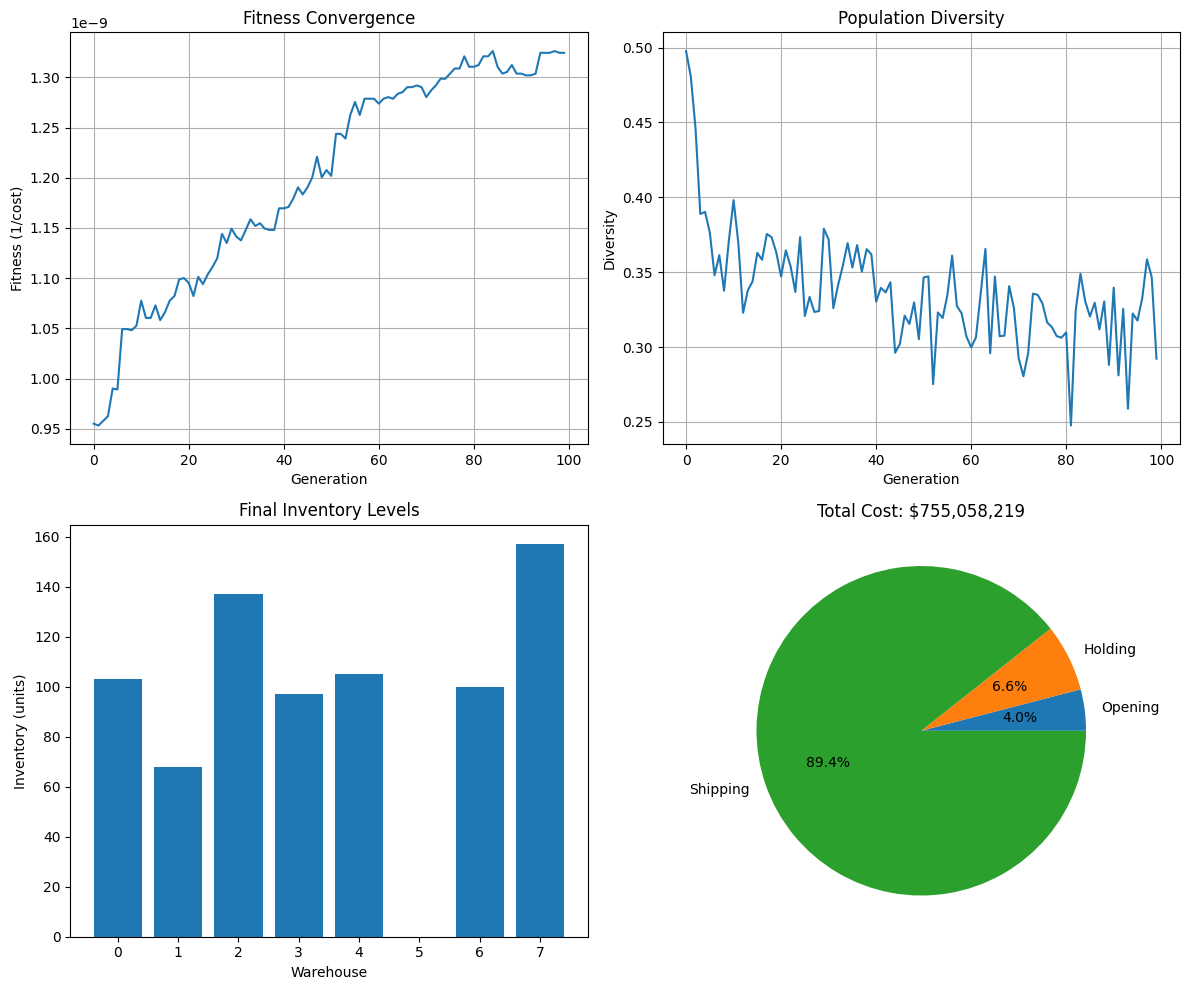


OPTIMIZATION COMPLETE


In [37]:
# ==============================================
# RUN THE GENETIC ALGORITHM
# ==============================================

print("=" * 50)
print("SUPPLY CHAIN OPTIMIZER - GENETIC ALGORITHM")
print("=" * 50)

# Step 1: Generate problem data
print("\n[1] Generating problem data...")
data = generate_supply_chain_data(W=8, C=30, seed=42)
print(f"    - Warehouses: {data['W']}")
print(f"    - Customers: {data['C']}")
print(f"    - Total demand: {sum(data['demand'])} units")

# Step 2: Run the GA
print("\n[2] Running Genetic Algorithm (200 generations)...")
print("-" * 50)

best_solutions, fitness_history, diversity_history = run_supply_chain_ga(
    data,
    pop_size=50,      # You can change this
    generations=100   # You can change this
)

# Step 3: Show final results
print("\n" + "=" * 50)
print("FINAL RESULTS")
print("=" * 50)

best = best_solutions[-1]
final_fitness, final_details = fitness_function(best, data)

print(f"\nTotal Cost: ${final_details['total_cost']:,.0f}")
print(f"Open Warehouses: {final_details['open_warehouses']} out of {data['W']}")
print(f"Unmet Demand: {final_details['unmet_demand']} units")
print(f"Shipping Cost: ${final_details['shipping_cost']:,.0f}")

# Step 4: Show which warehouses to open
print("\nWarehouse Plan:")
print("-" * 40)
print("WH# | Open? | Inventory | Capacity")
print("-" * 40)
for w in range(data['W']):
    status = "YES" if best.binary_part[w] == 1 else "NO"
    inv = best.get_inventory()[w]
    cap = data['max_capacity'][w]
    print(f"{w+1:2d}  |  {status}  |  {inv:5d}   |   {cap}")

# Step 5: Show cost breakdown
print("\nCost Breakdown:")
print("-" * 40)
opening = np.sum(best.binary_part * data['opening_cost'])
holding = np.sum(best.get_inventory() * data['holding_cost'])
shipping = final_details['shipping_cost']
print(f"Opening Cost:  ${opening:,.0f}")
print(f"Holding Cost:  ${holding:,.0f}")
print(f"Shipping Cost: ${shipping:,.0f}")
print(f"Total Cost:    ${final_details['total_cost']:,.0f}")

# Step 6: Plot graphs (if you have matplotlib)
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Plot 1: Fitness convergence
    axes[0,0].plot(fitness_history)
    axes[0,0].set_title('Fitness Convergence')
    axes[0,0].set_xlabel('Generation')
    axes[0,0].set_ylabel('Fitness (1/cost)')
    axes[0,0].grid(True)

    # Plot 2: Diversity
    axes[0,1].plot(diversity_history)
    axes[0,1].set_title('Population Diversity')
    axes[0,1].set_xlabel('Generation')
    axes[0,1].set_ylabel('Diversity')
    axes[0,1].grid(True)

    # Plot 3: Inventory levels
    axes[1,0].bar(range(data['W']), best.get_inventory())
    axes[1,0].set_title('Final Inventory Levels')
    axes[1,0].set_xlabel('Warehouse')
    axes[1,0].set_ylabel('Inventory (units)')

    # Plot 4: Cost breakdown pie chart
    costs = [opening, holding, shipping]
    labels = ['Opening', 'Holding', 'Shipping']
    axes[1,1].pie(costs, labels=labels, autopct='%1.1f%%')
    axes[1,1].set_title(f'Total Cost: ${final_details["total_cost"]:,.0f}')

    plt.tight_layout()
    plt.show()

except ImportError:
    print("\n[Matplotlib not installed - skipping graphs]")
    print("Install with: pip install matplotlib")

print("\n" + "=" * 50)
print("OPTIMIZATION COMPLETE")
print("=" * 50)